In [9]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import sys
import os

# Add the path to your 'src' folder dynamically
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '../../src')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src')))

# from data.feature_engineering import FeatureTechnicalIndicators, plot_feature_importance, select_features, add_hmm_features
from features.technical_indicators import FeatureTechnicalIndicators
from features.feature_selection import plot_feature_importance, select_features
from features.ml_features import add_hmm_features

In [10]:
# Load sample data
df = pd.read_csv('../datasets/btc_data_with_target.csv', parse_dates=['datetime'], index_col='datetime')

# Display data info
df.head()

,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,start_time_price-ohlcv,close,high,low,open,volume,start_time_open_interest,open_interest,future_return,target
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,1584064800000,5003.956097,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,1584068400000,5321.391317,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,1584072000000,4851.922211,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,1584075600000,4996.738882,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,1584079200000,5238.567725,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2


In [11]:
# 2. Basic technical indicators
print("\n2. Adding basic technical indicators...")
new_df = df.copy()
feature_technical = FeatureTechnicalIndicators(new_df, price_col='close')

# Add technical indicators
feature_technical.add_ema([5, 8, 13])
feature_technical.add_sma([50, 200])
feature_technical.add_rsi([14])
feature_technical.add_macd(fast_window=12, slow_window=26, signal_window=9)
feature_technical.add_price_change([1])

# Show added features by comparing with original DataFrame
added_features = list(set(new_df.columns) - set(df.columns))
print(f"Added {len(added_features)} features: {', '.join(added_features)}")
new_df.head()



2. Adding basic technical indicators...
Added 12 features: macd_trade_signal, ema_8, rsi_14_signal, ema_5_8_13_cross, macd, rsi_14, sma_200, price_change_1, sma_50, ema_5, macd_signal_flag, ema_13


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,ema_13,ema_5_8_13_cross,sma_50,sma_200,rsi_14,rsi_14_signal,macd,macd_signal_flag,macd_trade_signal,price_change_1
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5003.956097,0,NaN,NaN,NaN,0,0.000000,0,0.0,NaN
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5049.303986,1,NaN,NaN,NaN,0,25.322468,1,1.0,0.063437
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,5021.106589,0,NaN,NaN,NaN,0,7.422906,1,0.0,-0.088223
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,5017.625488,0,NaN,NaN,NaN,0,4.866768,-1,-2.0,0.029847
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5049.188665,1,NaN,NaN,NaN,0,22.099824,1,2.0,0.048397


In [12]:
# Add hmm features
print("\n3. Adding hmm features...")
# all the features except target
feature_cols = list(set(new_df.columns) - set(['target']))
new_df = new_df.dropna()
# Select features for HMM
# Need to train from scratch
# new_df = add_hmm_features(new_df, feature_cols, n_components=3, n_iter=1000, 
#                           save_model_path='model.pkl')

# Use pretrained model to add features
new_df = add_hmm_features(new_df, feature_cols, n_components=3, n_iter=1000, 
                          pretrained_model_path='model.pkl')


new_df


3. Adding hmm features...


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,ema_5_8_13_cross,sma_50,sma_200,rsi_14,rsi_14_signal,macd,macd_signal_flag,macd_trade_signal,price_change_1,hmm_state
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-21 10:00:00,1584784800000,1.655292e+13,1584784800000,0.068386,1584784800000,53529,35483,26362,1584784800000,0.379854,...,-1,6219.860852,5523.874562,50.425143,0,-52.206720,-1,0.0,0.000272,1
2020-03-21 11:00:00,1584788400000,1.655292e+13,1584788400000,0.070733,1584788400000,28680,18089,13601,1584788400000,0.420685,...,-1,6230.079459,5527.905558,44.655167,0,-49.705366,-1,0.0,0.024020,1
2020-03-21 12:00:00,1584792000000,1.655292e+13,1584792000000,0.069669,1584792000000,52721,32524,27993,1584792000000,0.736272,...,-1,6241.159378,5534.335002,48.718366,0,-46.363879,-1,0.0,0.001668,1
2020-03-21 13:00:00,1584795600000,1.655292e+13,1584795600000,0.069200,1584795600000,34129,22669,16683,1584795600000,0.515419,...,-1,6251.663416,5540.178737,47.935088,0,-41.009854,-1,0.0,0.004509,1
2020-03-21 14:00:00,1584799200000,1.655292e+13,1584799200000,0.069563,1584799200000,35403,21607,17842,1584799200000,0.779472,...,0,6257.966381,5544.949512,52.854334,0,-34.175021,-1,0.0,0.004418,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,1743444000000,1.137575e+14,1743444000000,0.162283,1743444000000,76251,38448,47636,1743444000000,0.846697,...,1,82660.339734,85414.981742,63.752812,0,148.984095,1,0.0,0.006807,1
2025-03-31 19:00:00,1743447600000,1.137575e+14,1743447600000,0.161615,1743447600000,59154,29711,36980,1743447600000,0.997602,...,1,82659.693620,85403.763828,51.857905,0,110.809464,1,0.0,-0.010128,1
2025-03-31 20:00:00,1743451200000,1.137575e+14,1743451200000,0.161152,1743451200000,71194,36194,44509,1743451200000,0.983015,...,0,82659.735916,85392.362712,53.745562,0,79.409292,1,0.0,-0.000035,1



4. Feature selection...

Top Features:
                             feature  importance
                       future_return    0.657089
                      price_change_1    0.072646
                    ema_5_8_13_cross    0.059364
                    taker_sell_ratio    0.056887
                     taker_buy_ratio    0.056887
                taker_buy_sell_ratio    0.056255
                              rsi_14    0.052857
coinbase_premium_index_usdt_adjusted    0.044686
                    macd_signal_flag    0.042455
                       rsi_14_signal    0.036884
  coinbase_premium_gap_usdt_adjusted    0.034411
                   macd_trade_signal    0.030390
                                macd    0.022632
              addresses_count_sender    0.017216
              addresses_count_active    0.017068
                         blockreward    0.015843
             tokens_transferred_mean    0.013464
                   long_liquidations    0.013461
            addresses_count_r

,future_return,price_change_1,ema_5_8_13_cross,taker_sell_ratio,taker_buy_ratio,taker_buy_sell_ratio,rsi_14,coinbase_premium_index_usdt_adjusted,macd_signal_flag,rsi_14_signal,...,macd_trade_signal,macd,addresses_count_sender,addresses_count_active,blockreward,tokens_transferred_mean,long_liquidations,addresses_count_receiver,taker_sell_volume,close
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-21 10:00:00,0.024020,0.000272,-1,0.431148,0.568852,1.319389,50.425143,-0.175436,-1,0,...,0.0,-52.206720,26362,53529,79.425701,4.404927,26.845000,35483,3.298779e+07,5983.856451
2020-03-21 11:00:00,0.001668,0.024020,-1,0.439940,0.560060,1.273038,44.655167,-0.156036,-1,0,...,0.0,-49.705366,13601,28680,38.953772,2.575115,175.261000,18089,5.907285e+07,6127.590660
2020-03-21 12:00:00,0.004509,0.001668,-1,0.455694,0.544306,1.194454,48.718366,-0.014339,-1,0,...,0.0,-46.363879,27993,52721,89.747683,2.304383,19.862000,32524,6.074075e+07,6137.810955
2020-03-21 13:00:00,0.004418,0.004509,-1,0.460852,0.539148,1.169896,47.935088,-0.064420,-1,0,...,0.0,-41.009854,16683,34129,77.994278,2.467700,53.855000,22669,5.132398e+07,6165.485900
2020-03-21 14:00:00,0.003962,0.004418,0,0.469738,0.530262,1.128848,52.854334,-0.176263,-1,0,...,0.0,-34.175021,17842,35403,52.579252,6.132433,53.725000,21607,4.301850e+07,6192.722682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,-0.010128,0.006807,1,0.488277,0.511723,1.048020,63.752812,-0.006184,1,0,...,0.0,148.984095,47636,76251,22.152889,1.676118,0.097000,38448,3.424566e+08,83287.446732
2025-03-31 19:00:00,-0.000035,-0.010128,1,0.531443,0.468557,0.881669,51.857905,-0.004337,1,0,...,0.0,110.809464,36980,59154,19.119721,1.976558,7.523869,29711,3.754510e+08,82443.899978
2025-03-31 20:00:00,0.001304,-0.000035,0,0.469972,0.530028,1.127787,53.745562,-0.000067,1,0,...,0.0,79.409292,44509,71194,31.509539,3.400298,0.464244,36194,2.203566e+08,82441.035723


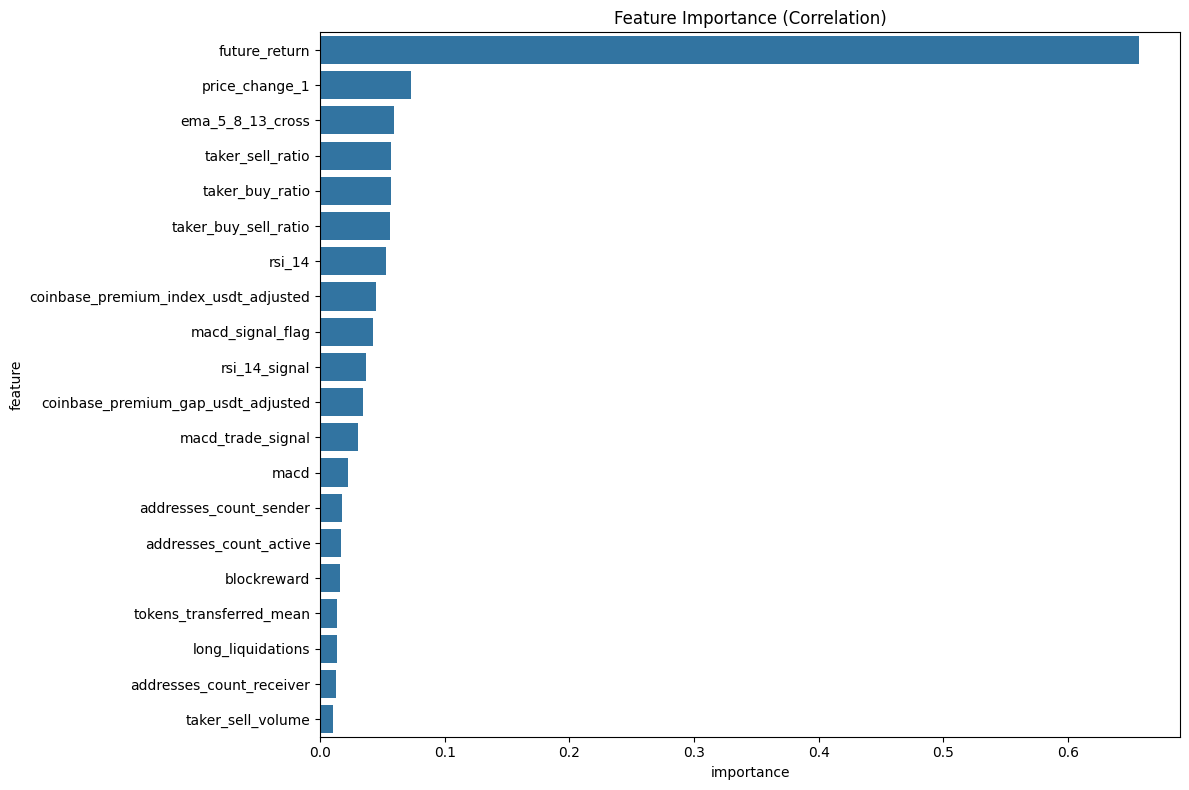

In [15]:
# 4. Feature selection
### NOTE: the target column should be the one you want to predict, i.e., 'buy' or 'sell' signal
print("\n4. Feature selection...") 
new_df2 = new_df.copy()

target_col = 'target'
X = new_df2.drop(columns=[target_col])
top10_all = plot_feature_importance(new_df2, target_col=target_col, feature_cols=list(X.columns), top_n=20, save_img_path='feature_importance_all.png', method='correlation')
print(f"Top 10 features (all): {top10_all}")

# Select features based on correlation
new_df2 = select_features(new_df2, features=top10_all + ['close'])
new_df2